In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da 
from tifffile import imwrite

pythonPackagePath = os.path.abspath(r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src')
sys.path.append(pythonPackagePath)
from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians

In [8]:
channel_to_detect = 3

base_dir =  r'\\10.158.28.194\ActiveNAS\Kenny'

# Define the file directory and name
input_file_directory = 'lumenoid_2_analysis/'
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'

zarr_full_path = os.path.join(base_dir, zarr_file_directory)

In [3]:
z2 = zarr.open(zarr_full_path, mode='r')

In [9]:
path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'
df = pd.read_pickle(path_to_detections).reset_index()

In [16]:
### AFTER TRACKING, OTHERWISE WILL THROW AN ERROR ####
path_to_tracks = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(path_to_tracks)
track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c2_vol_bg,c3_peak_mean,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg
0,0,126.0,523.0,34.0,533.0,2213,NaN,3,2,2,...,441,262.274286,556,45898,20724.315789,125,523,32,175,441
1,0,159.0,422.0,37.0,17.0,2212,NaN,3,2,2,...,441,6.511494,22,1133,268.909434,157,422,35,174,439
2,0,98.0,483.0,38.0,372.0,2222,NaN,3,2,2,...,441,168.908571,530,29559,2851.105263,99,485,41,175,441
3,0,90.0,533.0,38.0,36.0,2221,NaN,3,2,2,...,437,4.891566,36,812,288.160377,89,532,37,166,378
4,0,85.0,352.0,37.0,1199.0,2220,NaN,3,2,2,...,441,407.440000,1199,71302,32061.210526,85,351,36,175,441


In [6]:
# df.head()

In [7]:
# track_df.head()

In [11]:
# Create a napari viewer
viewer = napari.Viewer()

#access channel 3 only from zarr array 
dask_array = da.from_zarr(z2)

#the axis arrangement is (t,c,z,y,x)
# all_channels = dask_array[:,:,:,:,:]

# Import detection channel
detection_channel = dask_array[:, int(channel_to_detect)-1,:,:,:]


# Add the 4D stack to the viewer
# layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['Channel 1', 'Channel 2', 'Channel 3'])
# layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'], interpolation3d = 'nearest', blending = 'additive', colormap = 'gray_r', visible = [False, False, True])

layer_raw = viewer.add_image(detection_channel, name = 'fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'gray_r', visible = True)

#other useful parameters 
#color_map = list
#contrast_limits = list of list 

# Add Bounding Box
layer_raw.bounding_box.visible = True
# layer_raw[0].bounding_box.visible = True
# layer_raw[1].bounding_box.visible = True
# layer_raw[2].bounding_box.visible = True

#Visualising all dropped spots and the cleaned spots 
points_layer = viewer.add_points(df[["frame", "mu_z", "mu_y", "mu_x"]], size=3, 
                                name = 'Detected_Spots', face_color = 'lime', symbol = 'ring')


# points_layer = viewer.add_points(track_df[["frame", "mu_z", "mu_y", "mu_x"]], size=3, 
#                                 name = 'Spots_from_Tracking', face_color = '#aa0000', symbol = 'ring')

In [9]:
# from napari_animation import Animation

# animation = Animation(viewer)

# viewer.dims.ndisplay = 3
# viewer.scale_bar.visible = True
# # viewer.scale_bar.fixed_width = 50  # Adjust based on your data scale
# viewer.scale_bar.position = 'bottom_right'
# viewer.scale_bar.colored = True
# viewer.scale_bar.ticks = True
# viewer.camera.angles = (0.0, 0.0, 90.0)
# animation.capture_keyframe()
# viewer.camera.zoom = 8
# animation.capture_keyframe(steps = 80)
# viewer.camera.angles = (-7.0, 15.7, 62.4)
# animation.capture_keyframe(steps=150)

# # viewer.reset_view()
# # viewer.camera.angles = (0.0, 0.0, 90.0)
# # animation.capture_keyframe()
# animation.animate('demo.mov', canvas_only=False)

# # # Alternative: Export as GIF with specific settings
# # animation.animate('demo_enhanced.gif', canvas_only=False, fps=20)

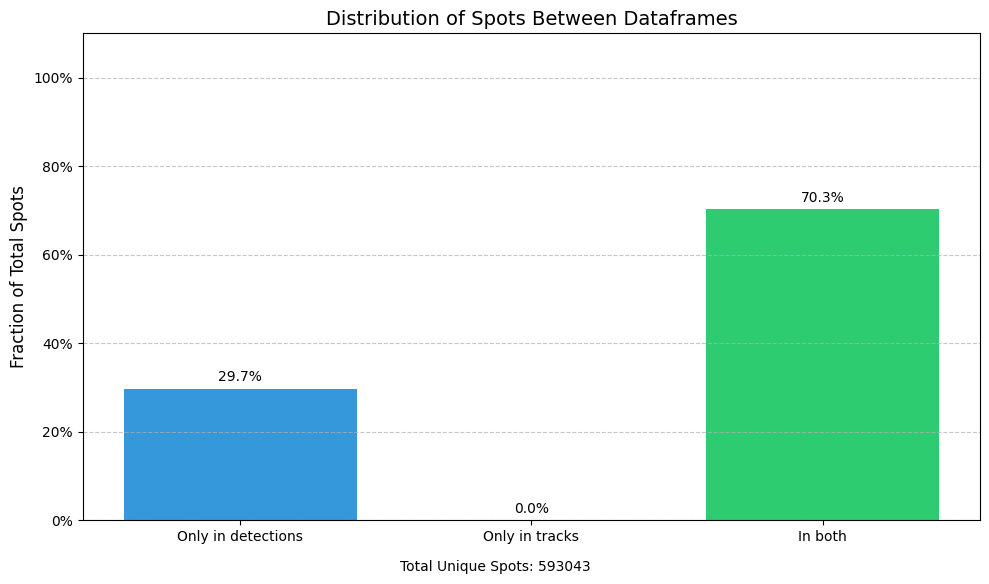

Spots only in df: 176061 (29.7%)
Spots only in track_df: 0 (0.0%)
Spots in both dataframes: 416982 (70.3%)
Total unique spots: 593043


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Define a function to identify unique spots based on coordinates
def compare_dataframes(df1, df2, tolerance=0.5):
    # Create a unique identifier for each spot by combining frame and coordinates
    # Round coordinates to handle potential float/int differences
    df1 = df1.copy()
    df2 = df2.copy()
    df1['spot_id'] = df1.apply(lambda row: f"{int(row['frame'])}_{round(row['mu_x'], 1)}_{round(row['mu_y'], 1)}_{round(row['mu_z'], 1)}", axis=1)
    df2['spot_id'] = df2.apply(lambda row: f"{int(row['frame'])}_{round(row['mu_x'], 1)}_{round(row['mu_y'], 1)}_{round(row['mu_z'], 1)}", axis=1)
    
    # Find spots only in df1
    only_in_df1 = df1[~df1['spot_id'].isin(df2['spot_id'])]
    
    # Find spots only in df2
    only_in_df2 = df2[~df2['spot_id'].isin(df1['spot_id'])]
    
    # Find spots in both
    in_both = df1[df1['spot_id'].isin(df2['spot_id'])]
    
    return {
        'only_in_df1': only_in_df1,
        'only_in_df2': only_in_df2,
        'in_both': in_both
    }

# Compare dataframes
result = compare_dataframes(df, track_df)

# Calculate counts
only_in_df_count = len(result['only_in_df1'])
only_in_track_df_count = len(result['only_in_df2'])
in_both_count = len(result['in_both'])
total_spots = only_in_df_count + only_in_track_df_count + in_both_count

# Calculate fractions
fractions = {
    'Only in detections': only_in_df_count / total_spots,
    'Only in tracks': only_in_track_df_count / total_spots,
    'In both': in_both_count / total_spots
}

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(fractions.keys(), fractions.values(), color=['#3498db', '#e74c3c', '#2ecc71'])

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom')

# Add titles and labels
plt.title('Distribution of Spots Between Dataframes', fontsize=14)
plt.ylabel('Fraction of Total Spots', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis limit to leave room for percentage labels
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
 
# Add total count information
plt.figtext(0.5, 0.01, f'Total Unique Spots: {total_spots}', ha='center', fontsize=10)

# Improve appearance
plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the text at the bottom
plt.savefig('spot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numeric results
print(f"Spots only in df: {only_in_df_count} ({fractions['Only in detections']:.1%})")
print(f"Spots only in track_df: {only_in_track_df_count} ({fractions['Only in tracks']:.1%})")
print(f"Spots in both dataframes: {in_both_count} ({fractions['In both']:.1%})")
print(f"Total unique spots: {total_spots}")

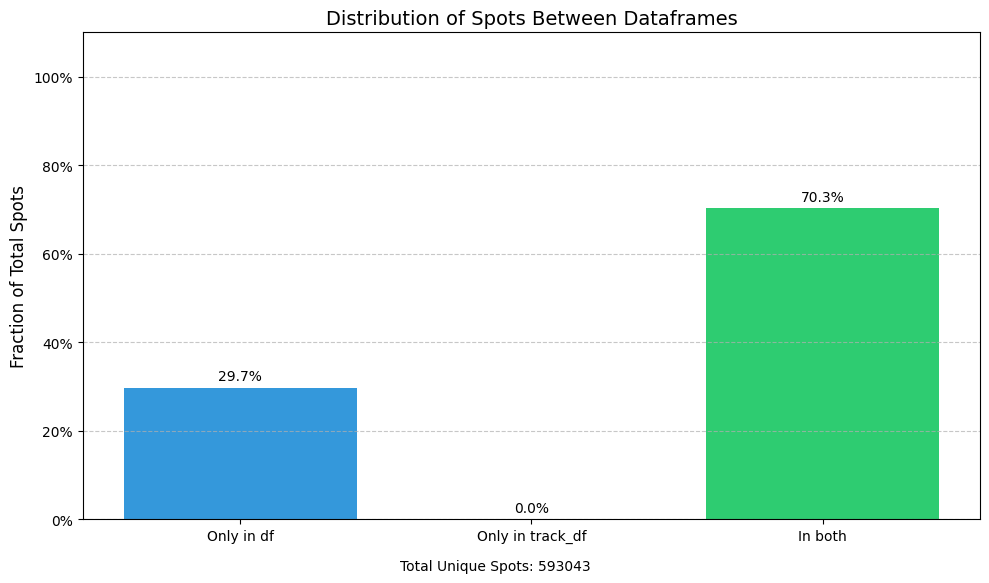

Spots only in df: 176061 (29.7%)
Spots only in track_df: 0 (0.0%)
Spots in both dataframes: 416982 (70.3%)
Total unique spots: 593043


In [12]:
# result['only_in_df1'][(result['only_in_df1']['frame'] == 26) & (result['only_in_df1']['mu_x'] == 215)]

In [13]:
# result['in_both'][(result['in_both']['frame'] == 26) & (result['in_both']['mu_x'] == 215)]

In [13]:
# Save a single slice as a tiff file
frame = 0
channel = 2
z_slice = 50

#Check how many detected spots are in the slice
len(df[(df['frame'] == frame) & (df['mu_z'] == z_slice)])

18

In [14]:
slice_data = z2[frame, channel, z_slice, :, :]
# Save the slice as a tiff file
# output_path = os.path.join(base_dir, input_file_directory, f'slice_frame_{frame}_channel_{channel}_z_{z_slice}.tiff')
# imwrite(output_path, slice_data.astype(np.uint16))

In [15]:
# Loading for a given Z-slice
frame_detections_z_slice = df[(df['frame'] == frame) & (df['mu_z'] == z_slice)]
output_detections_z_slice_path = os.path.join(base_dir, input_file_directory, f'detections_frame_{frame}_z_{z_slice}.csv')
# Create a DataFrame with the required columns for the Z-slice
detections_z_slice_df = pd.DataFrame({
    'x': frame_detections_z_slice['mu_x'],
    'y': frame_detections_z_slice['mu_y']
})
# Save the DataFrame to a CSV file for the Z-slice
# detections_z_slice_df.to_csv(output_detections_z_slice_path, index=False)